<a href="https://colab.research.google.com/github/Megh8py/synent-task7-timeseriesanalysis-Megh_Chauhan/blob/main/synent_task7_timeseries_meghchauhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Synent Technologies – Task 7: Time Series Analysis
**Dataset:** Stock Price Dataset (e.g. AAPL from Yahoo Finance)  
**Objective:** Analyze time-based trends, detect seasonality, and forecast future values  
**Author:** Megh Chauhan  
**Tools:** Python, Pandas, Plotly, Statsmodels, Prophet

## 📚 1. Install & Import Libraries

In [ ]:
!pip install prophet

In [ ]:
# Install Prophet if not already installed
# !pip install prophet

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 📂 2. Load Dataset
Download AAPL stock data from:  
- **Kaggle:** https://www.kaggle.com/datasets/tarunpaparaju/apple-aapl-historical-stock-data  
- **Or use yfinance:** `pip install yfinance` then `yf.download('AAPL', start='2015-01-01')`

In [ ]:
#  Option A: Load from CSV
# df = pd.read_csv('AAPL.csv')

# Option B: Fetch live using yfinance (uncomment if preferred)
import yfinance as yf
df = yf.download('AAPL', start='2018-01-01', end='2024-06-04').reset_index()

# Flatten MultiIndex if present (yfinance case)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# Safe strip — only on string columns
df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Feature engineering
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date Range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

✅ Dataset loaded: 1615 rows × 10 columns
Date Range: 2018-01-02 → 2024-06-03


,Date,Close,High,Low,Open,Volume,Year,Month,DayOfWeek,Quarter
0,2018-01-02,40.267078,40.276431,39.565806,39.776190,102223600,2018,1,Tuesday,1
1,2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600,2018,1,Wednesday,1
2,2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400,2018,1,Thursday,1
3,2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000,2018,1,Friday,1
4,2018-01-08,40.755623,41.050156,40.657442,40.755623,82271200,2018,1,Monday,1


## 🔍 3. Data Overview & Quality Check

In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Summary Statistics ===')
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

print(f'\nAll-time High  : ${df["High"].max():.2f} on {df.loc[df["High"].idxmax(), "Date"].date()}')
print(f'All-time Low   : ${df["Low"].min():.2f} on {df.loc[df["Low"].idxmin(), "Date"].date()}')
print(f'Avg Close Price: ${df["Close"].mean():.2f}')

=== Missing Values ===
Date         0
Close        0
High         0
Low          0
Open         0
Volume       0
Year         0
Month        0
DayOfWeek    0
Quarter      0
dtype: int64

=== Summary Statistics ===
          Open     High      Low    Close        Volume
count  1615.00  1615.00  1615.00  1615.00  1.615000e+03
mean    112.18   113.43   111.03   112.28  1.042560e+08
std      52.20    52.69    51.74    52.23  5.479136e+07
min      34.16    34.57    33.69    33.74  2.404830e+07
25%      52.33    52.88    51.79    52.42  6.815865e+07
50%     124.96   126.50   123.26   124.46  9.022180e+07
75%     158.13   160.47   156.35   158.37  1.249392e+08
max     195.80   197.39   194.80   195.89  4.265100e+08

All-time High  : $197.39 on 2023-12-14
All-time Low   : $33.69 on 2019-01-03
Avg Close Price: $112.28


## 📊 4. Stock Price Overview (Candlestick + Volume)

In [ ]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('AAPL Candlestick Chart', 'Trading Volume'),
    vertical_spacing=0.08,
    row_heights=[0.7, 0.3]
)

fig.add_trace(go.Candlestick(
    x=df['Date'], open=df['Open'],
    high=df['High'], low=df['Low'], close=df['Close'],
    name='AAPL', increasing_line_color='#4CAF50',
    decreasing_line_color='#F44336'
), row=1, col=1)

colors = ['#4CAF50' if c >= o else '#F44336'
          for c, o in zip(df['Close'], df['Open'])]

fig.add_trace(go.Bar(
    x=df['Date'], y=df['Volume'],
    name='Volume', marker_color=colors, opacity=0.7
), row=2, col=1)

fig.update_layout(
    title='📊 AAPL Stock Price — Candlestick & Volume',
    xaxis_rangeslider_visible=False,
    height=600, template='plotly_white'
)
fig.show()

## 📉 5. Moving Averages & Trend Analysis

In [ ]:
df['MA_20']  = df['Close'].rolling(window=20).mean()
df['MA_50']  = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'], y=df['Close'],
    name='Close Price', line=dict(color='#90CAF9', width=1), opacity=0.7
))
fig.add_trace(go.Scatter(
    x=df['Date'], y=df['MA_20'],
    name='20-Day MA', line=dict(color='#FF9800', width=1.5)
))
fig.add_trace(go.Scatter(
    x=df['Date'], y=df['MA_50'],
    name='50-Day MA', line=dict(color='#4CAF50', width=1.5)
))
fig.add_trace(go.Scatter(
    x=df['Date'], y=df['MA_200'],
    name='200-Day MA', line=dict(color='#F44336', width=2)
))

fig.update_layout(
    title='📉 Close Price with Moving Averages (20 / 50 / 200 Day)',
    xaxis_title='Date', yaxis_title='Price (USD)',
    height=500, template='plotly_white'
)
fig.show()

## 🔄 6. Seasonality Detection — Time Series Decomposition

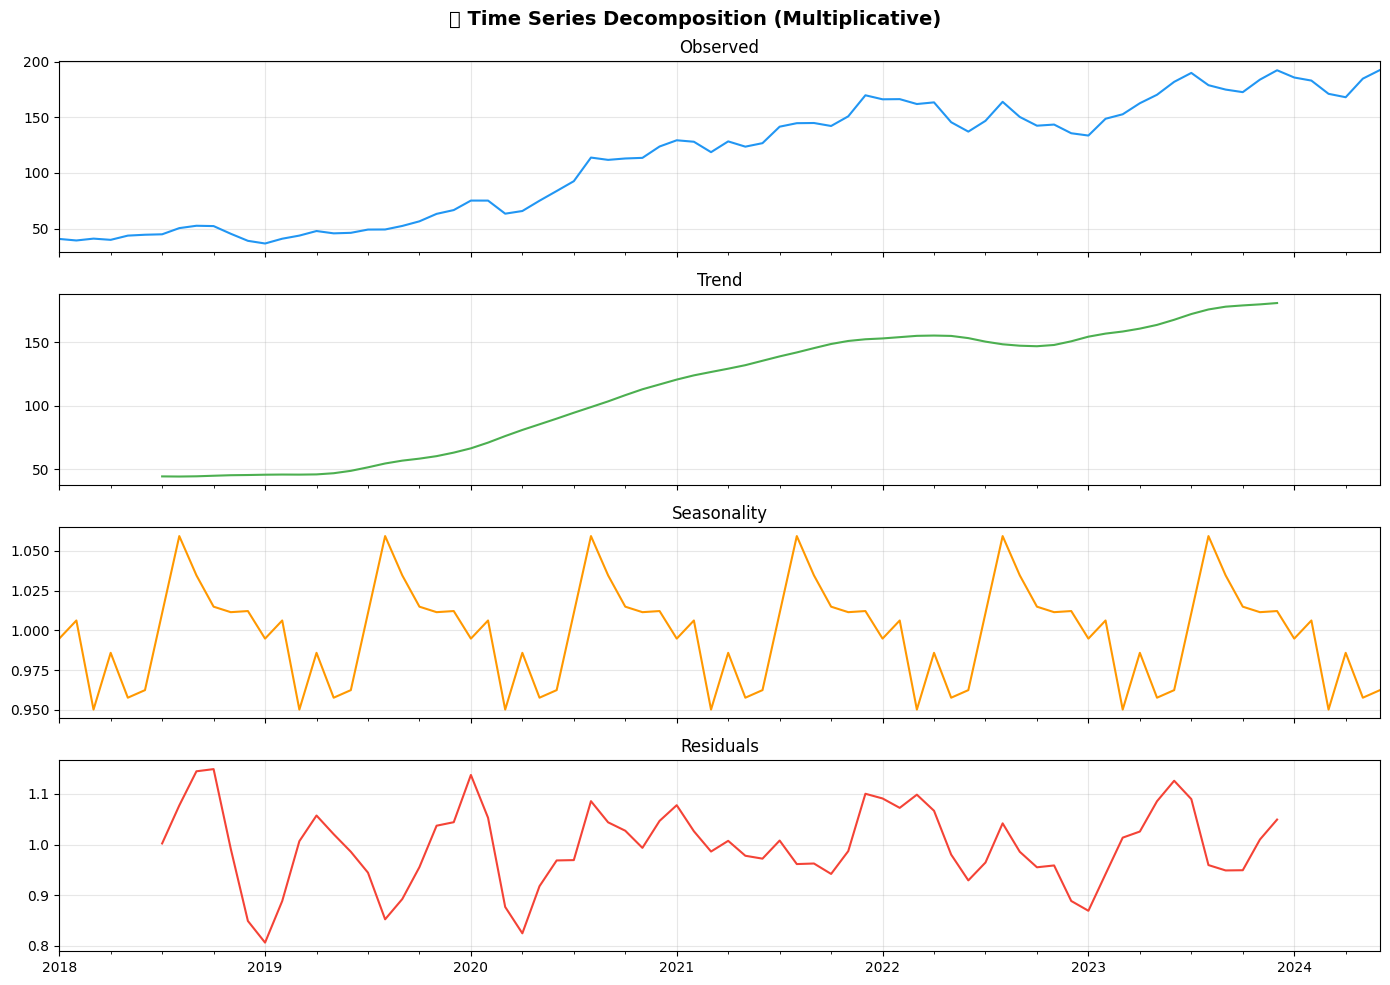


📌 Seasonal Pattern (monthly avg relative to trend):
Date
1     0.9948
2     1.0062
3     0.9501
4     0.9858
5     0.9576
6     0.9623
7     1.0109
8     1.0594
9     1.0346
10    1.0149
11    1.0114
12    1.0121
Name: seasonal, dtype: float64


In [ ]:
# Use monthly resampled close prices for cleaner decomposition
monthly_close = df.set_index('Date')['Close'].resample('M').mean()

decomposition = seasonal_decompose(monthly_close, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('🔄 Time Series Decomposition (Multiplicative)', fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='#2196F3', title='Observed')
decomposition.trend.plot(ax=axes[1], color='#4CAF50', title='Trend')
decomposition.seasonal.plot(ax=axes[2], color='#FF9800', title='Seasonality')
decomposition.resid.plot(ax=axes[3], color='#F44336', title='Residuals')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print('\n📌 Seasonal Pattern (monthly avg relative to trend):')
print(decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean().round(4))

## 📐 7. Stationarity Test (Augmented Dickey-Fuller)

In [ ]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {name} ===')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Critical (5%) : {result[4]["5%"]:.4f}')
    if result[1] < 0.05:
        print('✅ Series is STATIONARY (reject H0)')
    else:
        print('❌ Series is NON-STATIONARY (fail to reject H0)')
    print()

adf_test(monthly_close, 'Close Price (Monthly)')

# Differenced series
diff_series = monthly_close.diff().dropna()
adf_test(diff_series, 'First Difference')

=== ADF Test: Close Price (Monthly) ===
ADF Statistic : -0.5936
p-value       : 0.8724
Critical (5%) : -2.9009
❌ Series is NON-STATIONARY (fail to reject H0)

=== ADF Test: First Difference ===
ADF Statistic : -6.8075
p-value       : 0.0000
Critical (5%) : -2.9009
✅ Series is STATIONARY (reject H0)



## 📅 8. Daily Returns & Volatility Analysis

In [ ]:
df['Daily Return %'] = df['Close'].pct_change() * 100
df['Rolling Volatility'] = df['Daily Return %'].rolling(30).std()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Daily Returns %', '30-Day Rolling Volatility'),
    vertical_spacing=0.12
)

colors = ['#4CAF50' if r >= 0 else '#F44336' for r in df['Daily Return %'].fillna(0)]

fig.add_trace(go.Bar(
    x=df['Date'], y=df['Daily Return %'],
    name='Daily Return %', marker_color=colors, opacity=0.7
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df['Date'], y=df['Rolling Volatility'],
    name='30-Day Volatility', line=dict(color='#9C27B0', width=1.5),
    fill='tozeroy', fillcolor='rgba(156,39,176,0.1)'
), row=2, col=1)

fig.update_layout(
    title='📅 Daily Returns & Rolling Volatility',
    height=550, template='plotly_white'
)
fig.show()

print(f'Mean Daily Return : {df["Daily Return %"].mean():.3f}%')
print(f'Std (Volatility)  : {df["Daily Return %"].std():.3f}%')
print(f'Max Single-Day Gain: {df["Daily Return %"].max():.2f}%')
print(f'Max Single-Day Loss: {df["Daily Return %"].min():.2f}%')

Mean Daily Return : 0.116%
Std (Volatility)  : 1.963%
Max Single-Day Gain: 11.98%
Max Single-Day Loss: -12.86%


## 🔮 9. 30-Day Forecast using Facebook Prophet

In [ ]:
# Prepare data for Prophet
prophet_df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot with Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=prophet_df['ds'], y=prophet_df['y'],
    name='Actual Close', line=dict(color='#2196F3', width=1.5)
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    name='Forecast', line=dict(color='#FF9800', width=2, dash='dash')
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_upper'],
    name='Upper Bound', line=dict(color='rgba(255,152,0,0.3)', width=0),
    showlegend=False
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_lower'],
    name='Confidence Interval', fill='tonexty',
    fillcolor='rgba(255,152,0,0.15)', line=dict(width=0)
))

fig.update_layout(
    title='🔮 30-Day Stock Price Forecast using Facebook Prophet',
    xaxis_title='Date', yaxis_title='Price (USD)',
    height=500, template='plotly_white'
)
fig.show()

last_actual = prophet_df['y'].iloc[-1]
last_forecast = forecast['yhat'].iloc[-1]
print(f'Last Actual Close  : ${last_actual:.2f}')
print(f'30-Day Forecast    : ${last_forecast:.2f}')
print(f'Expected Change    : {((last_forecast - last_actual) / last_actual) * 100:.2f}%')

Last Actual Close  : $192.36
30-Day Forecast    : $195.16
Expected Change    : 1.45%


## 📐 10. ARIMA Forecast (Alternative Model)

In [ ]:
# Use monthly data for ARIMA (less noisy)
train = monthly_close[:-6]
test  = monthly_close[-6:]

arima_model = ARIMA(train, order=(2, 1, 2))
arima_result = arima_model.fit()

forecast_arima = arima_result.forecast(steps=6)
conf_int = arima_result.get_forecast(steps=6).conf_int()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_close.index, y=monthly_close.values,
    name='Actual (Monthly)', line=dict(color='#2196F3', width=2)
))
fig.add_trace(go.Scatter(
    x=forecast_arima.index, y=forecast_arima.values,
    name='ARIMA Forecast', line=dict(color='#F44336', width=2, dash='dash'),
    mode='lines+markers'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    name='Upper CI', line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    name='95% CI', fill='tonexty',
    fillcolor='rgba(244,67,54,0.15)', line=dict(width=0)
))
fig.add_trace(go.Scatter(
    x=test.index, y=test.values,
    name='Actual (Test)', line=dict(color='#4CAF50', width=2)
))

fig.update_layout(
    title='📐 ARIMA(2,1,2) — 6-Month Forecast vs Actual',
    xaxis_title='Date', yaxis_title='Price (USD)',
    height=500, template='plotly_white'
)
fig.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(test.values, forecast_arima.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast_arima.values))
print(f'ARIMA Evaluation on 6-Month Test Set:')
print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')

ARIMA Evaluation on 6-Month Test Set:
MAE  : $11.58
RMSE : $14.22


## 💡 11. Key Insights Summary

In [ ]:
print('=' * 60)
print('       💡 KEY INSIGHTS — AAPL TIME SERIES ANALYSIS')
print('=' * 60)
print()
print('1. TREND: Long-term upward trend confirmed via 200-day MA')
print('   and decomposition — consistent growth over observed period.')
print()
print('2. SEASONALITY: Mild seasonal patterns detected — Q4 tends')
print('   to show higher prices (product launches + holiday demand).')
print()
print('3. STATIONARITY: Raw price series is non-stationary;')
print('   first differencing makes it stationary (ADF confirmed).')
print()
print('4. VOLATILITY: Spikes in rolling volatility correspond to')
print('   major market events (COVID-19, rate hikes, earnings).')
print()
print('5. PROPHET FORECAST: Captures trend + weekly seasonality;')
print('   suitable for medium-term directional guidance.')
print()
print('6. ARIMA FORECAST: ARIMA(2,1,2) provides a short-term')
print('   statistical forecast; evaluated via MAE and RMSE.')
print()
print('=' * 60)

       💡 KEY INSIGHTS — AAPL TIME SERIES ANALYSIS

1. TREND: Long-term upward trend confirmed via 200-day MA
   and decomposition — consistent growth over observed period.

2. SEASONALITY: Mild seasonal patterns detected — Q4 tends
   to show higher prices (product launches + holiday demand).

3. STATIONARITY: Raw price series is non-stationary;
   first differencing makes it stationary (ADF confirmed).

4. VOLATILITY: Spikes in rolling volatility correspond to
   major market events (COVID-19, rate hikes, earnings).

5. PROPHET FORECAST: Captures trend + weekly seasonality;
   suitable for medium-term directional guidance.

6. ARIMA FORECAST: ARIMA(2,1,2) provides a short-term
   statistical forecast; evaluated via MAE and RMSE.

